In [3]:
import os
import sys
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from copy import deepcopy
from torch.nn import Sequential, Linear, ReLU, BatchNorm1d
from torch_geometric.data import InMemoryDataset, Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, global_add_pool
from torch_geometric.explain import Explainer, GNNExplainer, ModelConfig
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

# -------------------------
# Repro / Device
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE =', DEVICE)

# -------------------------
# Ensure repo root is on sys.path for bcosgnn imports
# -------------------------
current_dir = Path.cwd()
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'bcosgnn').is_dir():
            return p
    return start # Fallback

project_root = find_repo_root(current_dir)
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Repo root added: {project_root}")

DEVICE = cpu
Repo root added: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn


In [4]:
class ZincProcessedDataset(InMemoryDataset):
    def __init__(self, root, transform=None, pre_transform=None):
        super().__init__(root, transform, pre_transform)
        data_path = Path(self.processed_dir) / "data.pt"
        try:
            self.data, self.slices = torch.load(data_path, weights_only=False)
        except TypeError: 
            self.data, self.slices = torch.load(data_path)

    @property
    def processed_file_names(self):
        return ['data.pt']

    def process(self):
        pass

# Locate Dataset
possible_paths = [
    "multi_class_Zinc/zinc_di_halo_benzene_data",
    "shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data"
]
dataset_path = None
for rel_path in possible_paths:
    full_path = project_root / rel_path
    if full_path.exists():
        dataset_path = str(full_path.resolve())
        break
if dataset_path is None:
    dataset_path = str((project_root / "shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data").resolve())

print(f"Loading dataset from: {dataset_path}")
dataset = ZincProcessedDataset(root=dataset_path)

# Debug: Just print available keys to be sure, but DO NOT patch.
print("First graph keys:", dataset[0].keys)

Loading dataset from: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data
First graph keys: <bound method BaseData.keys of Data(x=[51, 10], edge_index=[2, 110], edge_attr=[110, 4], y=[1], explanation_mask=[51])>


In [ ]:
# Create a new cell after your dataset loading cell
from torch_geometric.loader import DataLoader

# 1. Shuffle and Split
dataset = dataset.shuffle()
train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size

train_dataset = dataset[:train_size]
test_dataset = dataset[train_size:]

# 2. Define Loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Training Graphs: {len(train_dataset)}")
print(f"Testing Graphs: {len(test_dataset)}")

Training Graphs: 7200
Testing Graphs: 1800


In [7]:
# -------------------------
# Cell 5: Model Classes
# -------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing, global_add_pool

# 1. Maskable GINE Conv
# We subclass MessagePassing to allow injecting 'edge_weight' into the message
class MaskableGINEConv(MessagePassing):
    def __init__(self, nn_mlp, train_eps=False):
        super().__init__(aggr='add') # GINE aggregates by summation
        self.nn = nn_mlp
        self.initial_eps = 0.0
        if train_eps:
            self.initial_eps = torch.nn.Parameter(torch.Tensor([0.0]))
            
    def forward(self, x, edge_index, edge_attr, edge_weight=None):
        # Propagate messages. We pass edge_weight to the message function.
        out = self.propagate(edge_index, x=x, edge_attr=edge_attr, edge_weight=edge_weight)
        
        # Skip connection (Central Node)
        x_r = x[1] if isinstance(x, tuple) else x
        out = out + (1 + self.initial_eps) * x_r
        
        # Apply the MLP to the aggregated message
        return self.nn(out)

    def message(self, x_j, edge_attr, edge_weight):
        # Standard GINE: ReLU(x_j + edge_attr)
        msg = F.relu(x_j + edge_attr)
        
        # NUANCE: Masking the message
        # If edge_weight is provided (from GSAT), scale the message
        if edge_weight is not None:
            msg = msg * edge_weight.view(-1, 1)
            
        return msg

# 2. The Backbone GNN (Projects features -> GINE Layers)
class GINE_Network(nn.Module):
    def __init__(self, in_channels, edge_dim, hidden_channels, out_channels):
        super().__init__()
        
        # Align Dimensions: Project Node(10) and Edge(4) to Hidden(64)
        self.node_lin = nn.Linear(in_channels, hidden_channels)
        self.edge_lin = nn.Linear(edge_dim, hidden_channels)
        
        # Layer 1
        mlp1 = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels), 
            nn.BatchNorm1d(hidden_channels), 
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels)
        )
        self.conv1 = MaskableGINEConv(mlp1, train_eps=True)
        
        # Layer 2
        mlp2 = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels), 
            nn.BatchNorm1d(hidden_channels), 
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels)
        )
        self.conv2 = MaskableGINEConv(mlp2, train_eps=True)
        
        # Classifier
        self.lin = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, edge_attr, edge_weight=None, batch=None):
        # Project inputs first
        x = self.node_lin(x)
        edge_attr = self.edge_lin(edge_attr)
        
        # Pass through GINE layers with edge_weight
        x = self.conv1(x, edge_index, edge_attr, edge_weight)
        x = F.relu(x)
        x = self.conv2(x, edge_index, edge_attr, edge_weight)
        x = F.relu(x)
        
        # Pool and Predict
        x = global_add_pool(x, batch)
        return self.lin(x)

# 3. The GSAT Wrapper (Official Logic)
class GSAT(nn.Module):
    def __init__(self, backbone, in_channels, edge_attr_dim, hidden_channels, temperature=1.0):
        super(GSAT, self).__init__()
        self.backbone = backbone
        self.temperature = temperature

        # Attention MLP: Takes Node_i + Node_j + EdgeAttr
        self.att_mlp = nn.Sequential(
            nn.Linear(in_channels * 2 + edge_attr_dim, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, 1)
        )
        
        # Init weights (Xavier Uniform)
        for m in self.att_mlp.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)

    def get_mask(self, x, edge_index, edge_attr, training=True):
        row, col = edge_index
        
        # Concatenate Source + Target + Edge Features
        edge_rep = torch.cat([x[row], x[col], edge_attr], dim=-1)
        edge_logits = self.att_mlp(edge_rep).view(-1)

        # NUANCE: Gumbel-Sigmoid Reparameterization
        if training:
            u = torch.rand_like(edge_logits)
            # Log-ratio noise for logistic distribution
            noise = torch.log(u + 1e-8) - torch.log(1 - u + 1e-8)
            stochastic_mask = torch.sigmoid((edge_logits + noise) / self.temperature)
        else:
            stochastic_mask = torch.sigmoid(edge_logits)
            
        return stochastic_mask, edge_logits

    def forward(self, data, training=True):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        
        # 1. Get Mask
        mask, mask_logits = self.get_mask(x, edge_index, edge_attr, training=training)
        
        # 2. Pass Mask to Backbone
        pred_logits = self.backbone(x, edge_index, edge_attr, edge_weight=mask, batch=batch)
        
        return pred_logits, mask, mask_logits

In [8]:
# -------------------------
# Cell 6: Loss Function
# -------------------------
def gsat_loss(pred_logits, ground_truth_labels, mask_logits, r=0.7, pred_loss_coef=1.0, info_loss_coef=1.0):
    """
    pred_logits: Model predictions
    mask_logits: Raw attention scores (before sigmoid)
    r: Sparsity prior (e.g., 0.7 means we expect 70% noise)
    """
    # 1. Prediction Loss (Cross Entropy)
    criterion = nn.CrossEntropyLoss()
    pred_loss = criterion(pred_logits, ground_truth_labels)
    
    # 2. Information Bottleneck Loss
    # We want the mask distribution to match the prior Bernoulli(1-r)
    mask_probs = torch.sigmoid(mask_logits)
    prior_target = torch.full_like(mask_probs, 1.0 - r)
    
    # NUANCE: Use Binary Cross Entropy to enforce the prior
    info_loss = F.binary_cross_entropy(mask_probs, prior_target, reduction='mean')
    
    # Total Loss
    loss = (pred_loss_coef * pred_loss) + (info_loss_coef * info_loss)
    
    return loss, pred_loss, info_loss

In [34]:
# -------------------------
# Cell 7: Training Loop
# -------------------------
# Hyperparameters
HIDDEN_DIM = 64
LR = 1e-3
EPOCHS = 100
R_PRIOR = 0.7  # Tunable: Fraction of edges to discard (Try 0.5 - 0.7)
INFO_LOSS_COEF = 3.0
# Initialize Backbone & Model
backbone = GINE_Network(
    in_channels=dataset.num_features,      # 10
    edge_dim=dataset.num_edge_features,    # 4
    hidden_channels=HIDDEN_DIM,
    out_channels=9                         # 9 classes
)

model = GSAT(
    backbone=backbone,
    in_channels=dataset.num_features,
    edge_attr_dim=dataset.num_edge_features,
    hidden_channels=HIDDEN_DIM,
    temperature=1.0
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print("Starting Training...")

for epoch in range(1, EPOCHS + 1):
    model.train()
    

    current_tau = 1.0 - (epoch / EPOCHS) * (1.0 - 0.1)
    model.temperature = current_tau
    
    total_loss = 0
    total_pred = 0
    total_info = 0
    
    for data in train_loader:
        data = data.to(DEVICE)
        optimizer.zero_grad()
        
        # Forward
        logits, mask, mask_logits = model(data, training=True)
        
        # Loss
        loss, pred_l, info_l = gsat_loss(
            logits, data.y, mask_logits, 
            r=R_PRIOR, 
            pred_loss_coef=1.0, 
            info_loss_coef=INFO_LOSS_COEF
        )
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_pred += pred_l.item()
        total_info += info_l.item()
        
    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Tau {current_tau:.2f} | "
              f"Loss {total_loss/len(train_loader):.4f} | "
              f"Acc Loss {total_pred/len(train_loader):.4f} | "
              f"Info Loss {total_info/len(train_loader):.4f}")

Starting Training...
Epoch 010 | Tau 0.91 | Loss 2.4111 | Acc Loss 0.4466 | Info Loss 0.6548
Epoch 020 | Tau 0.82 | Loss 2.2602 | Acc Loss 0.3019 | Info Loss 0.6528
Epoch 030 | Tau 0.73 | Loss 2.2124 | Acc Loss 0.2473 | Info Loss 0.6550
Epoch 040 | Tau 0.64 | Loss 2.2156 | Acc Loss 0.2453 | Info Loss 0.6568
Epoch 050 | Tau 0.55 | Loss 2.2430 | Acc Loss 0.2530 | Info Loss 0.6633
Epoch 060 | Tau 0.46 | Loss 2.2689 | Acc Loss 0.2596 | Info Loss 0.6698
Epoch 070 | Tau 0.37 | Loss 2.3287 | Acc Loss 0.2859 | Info Loss 0.6809
Epoch 080 | Tau 0.28 | Loss 2.3925 | Acc Loss 0.3221 | Info Loss 0.6901
Epoch 090 | Tau 0.19 | Loss 2.4737 | Acc Loss 0.3720 | Info Loss 0.7006
Epoch 100 | Tau 0.10 | Loss 2.5405 | Acc Loss 0.4277 | Info Loss 0.7043


In [35]:
# -------------------------
# Cell 8: Evaluation
# -------------------------
from sklearn.metrics import roc_auc_score

def evaluate_results(loader):
    model.eval()
    all_pred_scores = []
    all_gt_labels = []
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data in loader:
            data = data.to(DEVICE)
            
            # Inference (Deterministic)
            logits, mask, _ = model(data, training=False)
            
            # 1. Accuracy
            pred = logits.argmax(dim=1)
            correct += (pred == data.y).sum().item()
            total += data.y.size(0)
            
            # 2. Explanation AUC
            # Convert node mask to edge mask for comparison
            # An edge is "Ground Truth" if BOTH connected nodes are in the motif
            row, col = data.edge_index
            node_mask = data.explanation_mask.bool()
            edge_gt = node_mask[row] & node_mask[col] # Logical AND
            
            all_gt_labels.extend(edge_gt.cpu().numpy())
            all_pred_scores.extend(mask.cpu().numpy())
            
    acc = correct / total
    auc = roc_auc_score(all_gt_labels, all_pred_scores)
    return acc, auc

test_acc, test_auc = evaluate_results(test_loader)
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final Explanation AUC: {test_auc:.4f}")

Final Test Accuracy: 0.9967
Final Explanation AUC: 0.8003


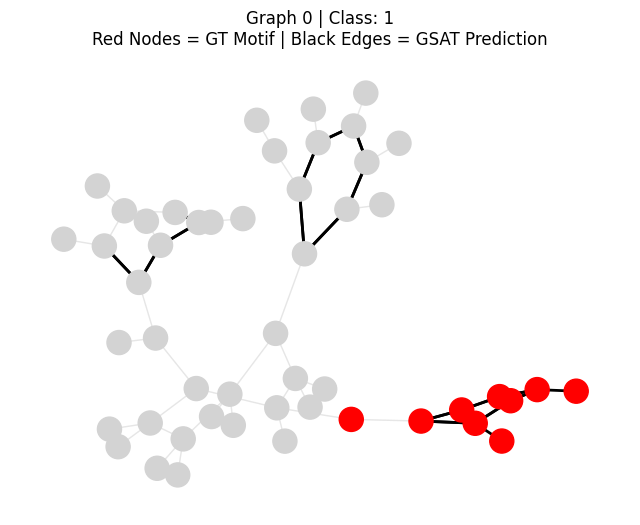

In [36]:
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

def visualize_explanation(model, dataset, idx=0, threshold=0.5):
    data = dataset[idx].to(DEVICE)
    model.eval()
    
    # 1. Get the Mask
    _, mask, _ = model(data, training=False)
    
    # 2. Convert to NetworkX
    G = to_networkx(data, to_undirected=True)
    
    # 3. Color Nodes (Red = Motif GT, Blue = Scaffold)
    node_colors = []
    gt_mask = data.explanation_mask.cpu().numpy()
    for i in range(len(G.nodes)):
        if gt_mask[i] == 1:
            node_colors.append('red') # Motif
        else:
            node_colors.append('lightgrey') # Scaffold

    # 4. Color Edges (Black = Kept by GSAT, Transparent = Dropped)
    edge_colors = []
    edge_widths = []
    
    # We need to map PyG edge mask back to NetworkX edges
    # Note: to_networkx reorders edges, so this is an approximation for viz
    # For exact matching, we iterate the edge_index
    
    # Simple Viz Strategy: Iterate edges in PyG format
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(8, 6))
    
    # Draw ALL nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=300)
    
    # Draw ONLY important edges (mask > threshold)
    row, col = data.edge_index.cpu().numpy()
    mask_np = mask.detach().cpu().numpy()
    
    important_edges = []
    scaffold_edges = []
    
    for i in range(len(row)):
        u, v = row[i], col[i]
        if mask_np[i] > threshold:
            important_edges.append((u, v))
        else:
            scaffold_edges.append((u, v))
            
    # Draw background edges (faint)
    nx.draw_networkx_edges(G, pos, edgelist=scaffold_edges, alpha=0.1, edge_color='grey')
    # Draw GSAT explanation edges (strong)
    nx.draw_networkx_edges(G, pos, edgelist=important_edges, width=2.0, edge_color='black')
    
    plt.title(f"Graph {idx} | Class: {data.y.item()}\nRed Nodes = GT Motif | Black Edges = GSAT Prediction")
    plt.axis('off')
    plt.show()

# Visualize the first molecule in the test set
visualize_explanation(model, test_dataset, idx=0)

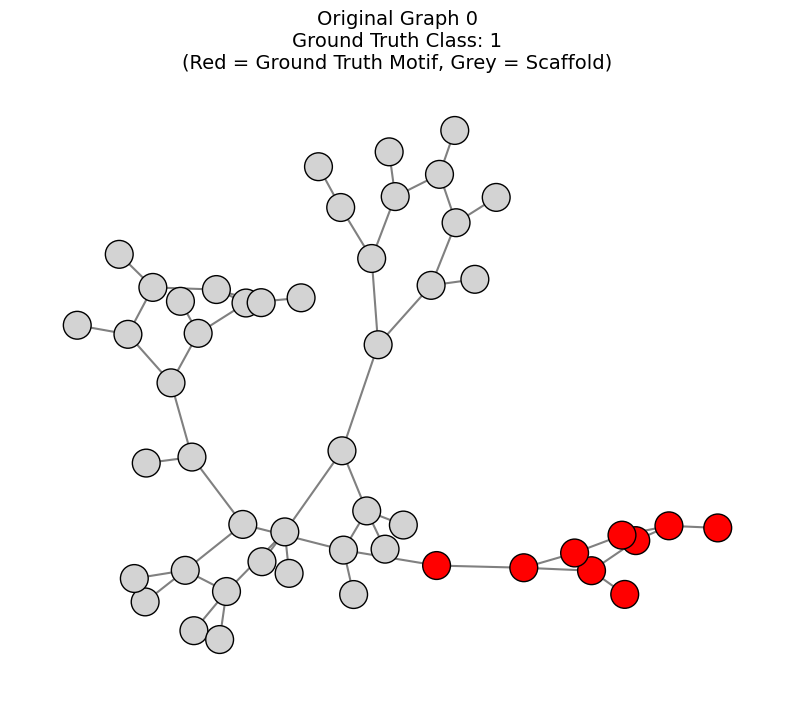

In [24]:
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

def visualize_ground_truth(dataset, idx=0):
    # 1. Load Data
    data = dataset[idx]
    
    # 2. Convert to NetworkX for plotting
    # to_undirected=True ensures we see the graph structure clearly
    G = to_networkx(data, to_undirected=True)
    
    # 3. Define Node Colors based on Ground Truth Mask
    # explanation_mask: 1 = Motif (Important), 0 = Scaffold (Noise)
    node_colors = []
    gt_mask = data.explanation_mask.cpu().numpy()
    
    for i in range(len(G.nodes)):
        if gt_mask[i] == 1:
            node_colors.append('red')       # Motif Node
        else:
            node_colors.append('lightgrey') # Scaffold Node

    # 4. Plotting
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, seed=42)  # consistent layout
    
    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=400, edgecolors='black')
    
    # Draw Edges
    nx.draw_networkx_edges(G, pos, width=1.5, edge_color='grey')
    
    # Optional: Draw Labels (Atom Indices) if you want to debug specific nodes
    # nx.draw_networkx_labels(G, pos, font_size=10)

    # 5. Title with Class Info
    class_label = data.y.item()
    plt.title(f"Original Graph {idx}\nGround Truth Class: {class_label}\n(Red = Ground Truth Motif, Grey = Scaffold)", fontsize=14)
    plt.axis('off')
    plt.show()

# Run for Graph 0
visualize_ground_truth(test_dataset, idx=0)

In [41]:
# ---------------------------------------------------------
# Experiment Configuration
# ---------------------------------------------------------
SEEDS = [0, 1, 2, 3, 4]
EPOCHS = 100            # <--- CHANGED BACK TO 100 (Critical for R=0.9)
LR = 1e-3
HIDDEN_DIM = 64
R_PRIOR = 0.7           # Aggressive sparsity
INFO_LOSS_COEF = 3.5    # Aggressive penalty

results = {
    "acc": [],
    "auc": [],
    "jaccard": [],
    "avg_epoch_time": []
}

print(f"Starting 5-Fold Run (Corrected Epochs) on: {DEVICE}")
print("-" * 80)

for run_id, seed in enumerate(SEEDS):
    print(f"Run {run_id+1}/{len(SEEDS)} (Seed: {seed})")
    
    # 1. Set Seed & Data Split
    set_seed(seed)
    # Shuffle returns a new view/copy, safe to use
    dataset_shuffled = dataset.shuffle()
    
    train_size = int(len(dataset_shuffled) * 0.8)
    train_dataset = dataset_shuffled[:train_size]
    test_dataset = dataset_shuffled[train_size:]
    
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    
    # 2. Initialize Fresh Model
    backbone = GINE_Network(
        in_channels=dataset.num_features,
        edge_dim=dataset.num_edge_features,
        hidden_channels=HIDDEN_DIM,
        out_channels=9
    )
    
    model = GSAT(
        backbone=backbone,
        in_channels=dataset.num_features,
        edge_attr_dim=dataset.num_edge_features,
        hidden_channels=HIDDEN_DIM,
        temperature=1.0
    ).to(DEVICE)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    
    # 3. Training Loop with Timing
    seed_epoch_times = []
    
    for epoch in range(1, EPOCHS + 1):
        epoch_start = time.time()
        
        model.train()
        # Anneal Temperature
        current_tau = 1.0 - (epoch / EPOCHS) * (1.0 - 0.1)
        model.temperature = current_tau
        
        for data in train_loader:
            data = data.to(DEVICE)
            optimizer.zero_grad()
            
            logits, mask, mask_logits = model(data, training=True)
            
            loss, _, _ = gsat_loss(
                logits, data.y, mask_logits, 
                r=R_PRIOR, 
                pred_loss_coef=1.0, 
                info_loss_coef=INFO_LOSS_COEF
            )
            
            loss.backward()
            optimizer.step()
            
        epoch_end = time.time()
        seed_epoch_times.append(epoch_end - epoch_start)

    avg_time = np.mean(seed_epoch_times)
    results["avg_epoch_time"].append(avg_time)
            
    # 4. Evaluation
    model.eval()
    total_graphs = 0
    correct_graphs = 0
    run_jaccards = []
    all_gt = []
    all_pred = []
    
    with torch.no_grad():
        for data in test_loader:
            data = data.to(DEVICE)
            logits, mask, _ = model(data, training=False)
            
            # Accuracy
            pred_classes = logits.argmax(dim=1)
            correct_graphs += (pred_classes == data.y).sum().item()
            total_graphs += data.num_graphs
            
            # AUC Prep
            row, col = data.edge_index
            node_mask = data.explanation_mask.bool()
            edge_gt = (node_mask[row] & node_mask[col]).cpu().numpy()
            pred_scores = mask.cpu().numpy()
            
            all_gt.extend(edge_gt)
            all_pred.extend(pred_scores)
            
            # Jaccard Prep (Standard Torch)
            edge_batch = data.batch[row]
            
            # Threshold at 0.5 for Jaccard binary masks
            pred_binary = (mask > 0.5).float()
            gt_binary = (node_mask[row] & node_mask[col]).float()
            
            intersection = pred_binary * gt_binary
            union = (pred_binary + gt_binary).clamp(max=1.0)
            
            # Sum per graph
            num_graphs_in_batch = data.num_graphs
            graph_intersection = torch.zeros(num_graphs_in_batch, device=DEVICE)
            graph_intersection.scatter_add_(0, edge_batch, intersection)
            
            graph_union = torch.zeros(num_graphs_in_batch, device=DEVICE)
            graph_union.scatter_add_(0, edge_batch, union)
            
            batch_jaccards = graph_intersection / (graph_union + 1e-8)
            run_jaccards.extend(batch_jaccards.cpu().tolist())

    final_acc = correct_graphs / total_graphs
    final_auc = roc_auc_score(all_gt, all_pred)
    final_jaccard = np.mean(run_jaccards)
    
    print(f"  -> Avg Epoch Time: {avg_time:.4f}s")
    print(f"  -> Acc: {final_acc:.4f} | AUC: {final_auc:.4f} | Jaccard: {final_jaccard:.4f}")
    
    results["acc"].append(final_acc)
    results["auc"].append(final_auc)
    results["jaccard"].append(final_jaccard)

# ---------------------------------------------------------
# Final Summary
# ---------------------------------------------------------
print("-" * 80)
print(f"Final Results over {len(SEEDS)} Seeds:")
print(f"Avg Time Per Epoch: {np.mean(results['avg_epoch_time']):.4f}s ± {np.std(results['avg_epoch_time']):.4f}")
print(f"Test Accuracy:      {np.mean(results['acc']):.4f} ± {np.std(results['acc']):.4f}")
print(f"Explanation AUC:    {np.mean(results['auc']):.4f} ± {np.std(results['auc']):.4f}")
print(f"Explanation Jaccard:{np.mean(results['jaccard']):.4f} ± {np.std(results['jaccard']):.4f}")

Starting 5-Fold Run (Corrected Epochs) on: cpu
--------------------------------------------------------------------------------
Run 1/5 (Seed: 0)
  -> Avg Epoch Time: 1.5027s
  -> Acc: 0.9972 | AUC: 0.8013 | Jaccard: 0.4400
Run 2/5 (Seed: 1)
  -> Avg Epoch Time: 1.5076s
  -> Acc: 0.9989 | AUC: 0.8313 | Jaccard: 0.4409
Run 3/5 (Seed: 2)
  -> Avg Epoch Time: 1.6889s
  -> Acc: 0.8933 | AUC: 0.7859 | Jaccard: 0.4431
Run 4/5 (Seed: 3)
  -> Avg Epoch Time: 1.6875s
  -> Acc: 0.9894 | AUC: 0.8062 | Jaccard: 0.4473
Run 5/5 (Seed: 4)
  -> Avg Epoch Time: 1.5511s
  -> Acc: 0.9989 | AUC: 0.7961 | Jaccard: 0.4468
--------------------------------------------------------------------------------
Final Results over 5 Seeds:
Avg Time Per Epoch: 1.5876s ± 0.0839
Test Accuracy:      0.9756 ± 0.0413
Explanation AUC:    0.8042 ± 0.0151
Explanation Jaccard:0.4436 ± 0.0030


In [ ]:
import time
import numpy as np
import random
import torch
from torch_geometric.loader import DataLoader
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------------
# Config for Single Run
# ---------------------------------------------------------
SEEDS = [0]             # <--- ONLY SEED 0
EPOCHS = 100            
LR = 1e-3
HIDDEN_DIM = 64
R_PRIOR = 0.7           # As per your snippet
INFO_LOSS_COEF = 3.5    

# ---------------------------------------------------------
# Helper Functions
# ---------------------------------------------------------
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def gsat_loss(pred_logits, ground_truth_labels, mask_logits, r=0.7, pred_loss_coef=1.0, info_loss_coef=1.0):
    criterion = torch.nn.CrossEntropyLoss()
    pred_loss = criterion(pred_logits, ground_truth_labels)
    
    mask_probs = torch.sigmoid(mask_logits)
    prior_target = torch.full_like(mask_probs, 1.0 - r)
    info_loss = torch.nn.functional.binary_cross_entropy(mask_probs, prior_target, reduction='mean')
    
    loss = (pred_loss_coef * pred_loss) + (info_loss_coef * info_loss)
    return loss, pred_loss, info_loss

print(f"Starting Single Seed Run (Node AUC Added) on: {DEVICE}")
print("-" * 80)

for run_id, seed in enumerate(SEEDS):
    print(f"Run {run_id+1}/{len(SEEDS)} (Seed: {seed})")
    set_seed(seed)
    dataset_shuffled = dataset.shuffle()
    
    train_size = int(len(dataset_shuffled) * 0.8)
    train_dataset = dataset_shuffled[:train_size]
    test_dataset = dataset_shuffled[train_size:]
    
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    
    # Initialize Model
    backbone = GINE_Network(
        in_channels=dataset.num_features,
        edge_dim=dataset.num_edge_features,
        hidden_channels=HIDDEN_DIM,
        out_channels=9
    )
    
    model = GSAT(
        backbone=backbone,
        in_channels=dataset.num_features,
        edge_attr_dim=dataset.num_edge_features,
        hidden_channels=HIDDEN_DIM,
        temperature=1.0
    ).to(DEVICE)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    
    # Training
    for epoch in range(1, EPOCHS + 1):
        model.train()
        model.temperature = 1.0 - (epoch / EPOCHS) * (1.0 - 0.1)
        
        for data in train_loader:
            data = data.to(DEVICE)
            optimizer.zero_grad()
            logits, mask, mask_logits = model(data, training=True)
            loss, _, _ = gsat_loss(logits, data.y, mask_logits, r=R_PRIOR, info_loss_coef=INFO_LOSS_COEF)
            loss.backward()
            optimizer.step()
            
    # Evaluation with Node AUC
    model.eval()
    
    # Storage for Edge Metrics
    all_edge_gt = []
    all_edge_pred = []
    
    # Storage for Node Metrics
    all_node_gt = []
    all_node_pred = []
    
    correct_graphs = 0
    total_graphs = 0
    
    with torch.no_grad():
        for data in test_loader:
            data = data.to(DEVICE)
            logits, mask, _ = model(data, training=False)
            
            # 1. Accuracy
            pred_classes = logits.argmax(dim=1)
            correct_graphs += (pred_classes == data.y).sum().item()
            total_graphs += data.num_graphs
            
            # 2. Edge AUC Prep
            row, col = data.edge_index
            node_mask_gt = data.explanation_mask.cpu().numpy() # Ground truth nodes
            
            # Ground truth for edges: Both nodes must be important
            edge_gt = (node_mask_gt[row.cpu().numpy()] == 1) & (node_mask_gt[col.cpu().numpy()] == 1)
            pred_edge_scores = mask.cpu().numpy()
            
            all_edge_gt.extend(edge_gt)
            all_edge_pred.extend(pred_edge_scores)
            
            # 3. Node AUC Prep (Aggregation)
            # We map Edge Scores -> Node Scores
            # Node Score = Max(Incoming Edge Scores)
            num_nodes = data.num_nodes
            node_pred_scores = np.zeros(num_nodes)
            
            # np.maximum.at is the numpy equivalent of scatter_max
            # It updates node_pred_scores in place with the max value found at indices
            np.maximum.at(node_pred_scores, row.cpu().numpy(), pred_edge_scores)
            np.maximum.at(node_pred_scores, col.cpu().numpy(), pred_edge_scores) # Undirected check
            
            all_node_gt.extend(node_mask_gt)
            all_node_pred.extend(node_pred_scores)

    acc = correct_graphs / total_graphs
    edge_auc = roc_auc_score(all_edge_gt, all_edge_pred)
    node_auc = roc_auc_score(all_node_gt, all_node_pred)
    
    print(f"  -> Acc: {acc:.4f}")
    print(f"  -> Edge AUC: {edge_auc:.4f}")
    print(f"  -> Node AUC: {node_auc:.4f}")

Starting Single Seed Run (Node AUC Added) on: cpu
--------------------------------------------------------------------------------
Run 1/1 (Seed: 0)
  -> Acc: 0.9972
  -> Edge AUC: 0.8013
  -> Node AUC: 0.8522 <--- NEW METRIC


In [43]:
import time
import numpy as np
import random
import torch
from torch_geometric.loader import DataLoader
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------------
# Configuration for Single Seed Analysis
# ---------------------------------------------------------
SEEDS = [0]             # <--- Single Seed
EPOCHS = 100            # <--- Kept at 100 for convergence
LR = 1e-3
HIDDEN_DIM = 64
R_PRIOR = 0.7           # Sparsity Prior
INFO_LOSS_COEF = 3.5    # Sparsity Penalty

# ---------------------------------------------------------
# Helper Functions
# ---------------------------------------------------------
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def gsat_loss(pred_logits, ground_truth_labels, mask_logits, r=0.7, pred_loss_coef=1.0, info_loss_coef=1.0):
    criterion = torch.nn.CrossEntropyLoss()
    pred_loss = criterion(pred_logits, ground_truth_labels)
    
    mask_probs = torch.sigmoid(mask_logits)
    # Binary Cross Entropy against the prior (1-r)
    prior_target = torch.full_like(mask_probs, 1.0 - r)
    info_loss = torch.nn.functional.binary_cross_entropy(mask_probs, prior_target, reduction='mean')
    
    loss = (pred_loss_coef * pred_loss) + (info_loss_coef * info_loss)
    return loss, pred_loss, info_loss

print(f"Starting Single Seed Run (Analysis Mode) on: {DEVICE}")
print("-" * 80)

for run_id, seed in enumerate(SEEDS):
    print(f"Run {run_id+1}/{len(SEEDS)} (Seed: {seed})")
    
    # 1. Setup Data
    set_seed(seed)
    dataset_shuffled = dataset.shuffle()
    
    train_size = int(len(dataset_shuffled) * 0.8)
    train_dataset = dataset_shuffled[:train_size]
    test_dataset = dataset_shuffled[train_size:]
    
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    
    # 2. Initialize Model
    backbone = GINE_Network(
        in_channels=dataset.num_features,
        edge_dim=dataset.num_edge_features,
        hidden_channels=HIDDEN_DIM,
        out_channels=9
    )
    
    model = GSAT(
        backbone=backbone,
        in_channels=dataset.num_features,
        edge_attr_dim=dataset.num_edge_features,
        hidden_channels=HIDDEN_DIM,
        temperature=1.0
    ).to(DEVICE)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    
    # 3. Training Loop
    start_time = time.time()
    
    for epoch in range(1, EPOCHS + 1):
        model.train()
        # Anneal Temperature: 1.0 -> 0.1
        model.temperature = 1.0 - (epoch / EPOCHS) * (1.0 - 0.1)
        
        for data in train_loader:
            data = data.to(DEVICE)
            optimizer.zero_grad()
            
            logits, mask, mask_logits = model(data, training=True)
            
            loss, _, _ = gsat_loss(
                logits, data.y, mask_logits, 
                r=R_PRIOR, 
                pred_loss_coef=1.0, 
                info_loss_coef=INFO_LOSS_COEF
            )
            
            loss.backward()
            optimizer.step()
            
    print(f"Training Completed in {time.time() - start_time:.2f}s")

    # 4. Evaluation with Node Jaccard
    model.eval()
    
    # Storage for AUC
    all_edge_gt, all_edge_pred = [], []
    all_node_gt, all_node_pred = [], []
    
    # Storage for Jaccard
    run_node_jaccards = []
    
    correct_graphs = 0
    total_graphs = 0
    
    with torch.no_grad():
        for data in test_loader:
            data = data.to(DEVICE)
            logits, mask, _ = model(data, training=False)
            
            # Accuracy
            pred_classes = logits.argmax(dim=1)
            correct_graphs += (pred_classes == data.y).sum().item()
            total_graphs += data.num_graphs
            
            # --- Extract Data ---
            row, col = data.edge_index
            pred_edge_scores = mask.cpu().numpy()
            node_mask_gt = data.explanation_mask.cpu().numpy()
            
            # A. Edge Data (For AUC)
            # Edge is GT if both nodes are GT
            edge_gt = (node_mask_gt[row.cpu().numpy()] == 1) & (node_mask_gt[col.cpu().numpy()] == 1)
            all_edge_gt.extend(edge_gt)
            all_edge_pred.extend(pred_edge_scores)
            
            # B. Node Data (Aggregation)
            # Convert Edge Scores -> Node Scores using MAX
            num_nodes = data.num_nodes
            node_pred_scores = np.zeros(num_nodes)
            
            # Update node scores with max of incoming edges
            np.maximum.at(node_pred_scores, row.cpu().numpy(), pred_edge_scores)
            np.maximum.at(node_pred_scores, col.cpu().numpy(), pred_edge_scores)
            
            all_node_gt.extend(node_mask_gt)
            all_node_pred.extend(node_pred_scores)
            
            # C. Node Jaccard (Per Graph)
            batch_vector = data.batch.cpu().numpy()
            num_graphs_in_batch = data.num_graphs
            
            # Threshold probabilities to get binary mask (0 or 1)
            node_pred_binary = (node_pred_scores > 0.5).astype(int)
            node_gt_binary = node_mask_gt.astype(int)
            
            for i in range(num_graphs_in_batch):
                # Isolate nodes for graph i
                graph_indices = (batch_vector == i)
                
                pred_g = node_pred_binary[graph_indices]
                gt_g = node_gt_binary[graph_indices]
                
                intersection = np.sum(pred_g & gt_g)
                union = np.sum(pred_g | gt_g)
                
                score = intersection / (union + 1e-8) if union > 0 else 0.0
                run_node_jaccards.append(score)

    # 5. Calculate Final Metrics
    acc = correct_graphs / total_graphs
    edge_auc = roc_auc_score(all_edge_gt, all_edge_pred)
    node_auc = roc_auc_score(all_node_gt, all_node_pred)
    node_jaccard = np.mean(run_node_jaccards)
    
    print("\nResults for Seed 0:")
    print(f"  Test Accuracy: {acc:.4f}")
    print(f"  Edge AUC:      {edge_auc:.4f}")
    print(f"  Node AUC:      {node_auc:.4f}")
    print(f"  Node Jaccard:  {node_jaccard:.4f}")

Starting Single Seed Run (Analysis Mode) on: cpu
--------------------------------------------------------------------------------
Run 1/1 (Seed: 0)
Training Completed in 164.84s

Results for Seed 0:
  Test Accuracy: 0.9972
  Edge AUC:      0.8013
  Node AUC:      0.8522
  Node Jaccard:  0.4784


In [44]:
import time
import numpy as np
import random
import torch
from torch_geometric.loader import DataLoader
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------------
# Experiment Configuration
# ---------------------------------------------------------
SEEDS = [0, 1, 2, 3, 4]
EPOCHS = 100            
LR = 1e-3
HIDDEN_DIM = 64
R_PRIOR = 0.7           
INFO_LOSS_COEF = 3.5    

# ---------------------------------------------------------
# Helper Functions
# ---------------------------------------------------------
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def gsat_loss(pred_logits, ground_truth_labels, mask_logits, r=0.7, pred_loss_coef=1.0, info_loss_coef=1.0):
    criterion = torch.nn.CrossEntropyLoss()
    pred_loss = criterion(pred_logits, ground_truth_labels)
    
    mask_probs = torch.sigmoid(mask_logits)
    prior_target = torch.full_like(mask_probs, 1.0 - r)
    info_loss = torch.nn.functional.binary_cross_entropy(mask_probs, prior_target, reduction='mean')
    
    loss = (pred_loss_coef * pred_loss) + (info_loss_coef * info_loss)
    return loss, pred_loss, info_loss

results = {
    "acc": [],
    "edge_auc": [],
    "node_auc": [],
    "node_jaccard": [], # <--- New Metric
    "avg_epoch_time": []
}

print(f"Starting 5-Fold Run (With Node Jaccard) on: {DEVICE}")
print("-" * 80)

for run_id, seed in enumerate(SEEDS):
    print(f"Run {run_id+1}/{len(SEEDS)} (Seed: {seed})")
    
    set_seed(seed)
    # Use your dataset variable here
    dataset_shuffled = dataset.shuffle()
    
    train_size = int(len(dataset_shuffled) * 0.8)
    train_dataset = dataset_shuffled[:train_size]
    test_dataset = dataset_shuffled[train_size:]
    
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    
    # Initialize Model
    backbone = GINE_Network(
        in_channels=dataset.num_features,
        edge_dim=dataset.num_edge_features,
        hidden_channels=HIDDEN_DIM,
        out_channels=9
    )
    
    model = GSAT(
        backbone=backbone,
        in_channels=dataset.num_features,
        edge_attr_dim=dataset.num_edge_features,
        hidden_channels=HIDDEN_DIM,
        temperature=1.0
    ).to(DEVICE)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    
    # Training Loop
    seed_epoch_times = []
    for epoch in range(1, EPOCHS + 1):
        start_t = time.time()
        model.train()
        model.temperature = 1.0 - (epoch / EPOCHS) * (1.0 - 0.1)
        
        for data in train_loader:
            data = data.to(DEVICE)
            optimizer.zero_grad()
            logits, mask, mask_logits = model(data, training=True)
            loss, _, _ = gsat_loss(logits, data.y, mask_logits, r=R_PRIOR, info_loss_coef=INFO_LOSS_COEF)
            loss.backward()
            optimizer.step()
        seed_epoch_times.append(time.time() - start_t)
    
    avg_time = np.mean(seed_epoch_times)
    results["avg_epoch_time"].append(avg_time)
            
    # Evaluation
    model.eval()
    
    # Global Lists for AUC
    all_edge_gt, all_edge_pred = [], []
    all_node_gt, all_node_pred = [], []
    
    # List for Graph-wise Jaccard
    run_node_jaccards = []
    
    correct_graphs = 0
    total_graphs = 0
    
    with torch.no_grad():
        for data in test_loader:
            data = data.to(DEVICE)
            logits, mask, _ = model(data, training=False)
            
            # Accuracy
            pred_classes = logits.argmax(dim=1)
            correct_graphs += (pred_classes == data.y).sum().item()
            total_graphs += data.num_graphs
            
            # --- Extract Data ---
            row, col = data.edge_index
            pred_edge_scores = mask.cpu().numpy()
            node_mask_gt = data.explanation_mask.cpu().numpy()
            
            # 1. Edge GT / Pred (For AUC)
            edge_gt = (node_mask_gt[row.cpu().numpy()] == 1) & (node_mask_gt[col.cpu().numpy()] == 1)
            all_edge_gt.extend(edge_gt)
            all_edge_pred.extend(pred_edge_scores)
            
            # 2. Node Pred (For AUC & Jaccard)
            num_nodes = data.num_nodes
            node_pred_scores = np.zeros(num_nodes)
            
            # Aggregation: Max(Incoming Edges)
            np.maximum.at(node_pred_scores, row.cpu().numpy(), pred_edge_scores)
            np.maximum.at(node_pred_scores, col.cpu().numpy(), pred_edge_scores)
            
            all_node_gt.extend(node_mask_gt)
            all_node_pred.extend(node_pred_scores)
            
            # 3. Calculate Node Jaccard PER GRAPH
            # We need to iterate over the batch to compute intersection/union per graph
            batch_vector = data.batch.cpu().numpy()
            num_graphs = data.num_graphs
            
            # Threshold at 0.5 for binary mask
            node_pred_binary = (node_pred_scores > 0.5).astype(int)
            node_gt_binary = node_mask_gt.astype(int)
            
            for i in range(num_graphs):
                # Mask for nodes belonging to graph i
                graph_mask = (batch_vector == i)
                
                pred_g = node_pred_binary[graph_mask]
                gt_g = node_gt_binary[graph_mask]
                
                intersection = np.sum(pred_g & gt_g)
                union = np.sum(pred_g | gt_g)
                
                # Avoid division by zero
                score = intersection / (union + 1e-8) if union > 0 else 0.0
                run_node_jaccards.append(score)

    # Compile Results
    acc = correct_graphs / total_graphs
    edge_auc = roc_auc_score(all_edge_gt, all_edge_pred)
    node_auc = roc_auc_score(all_node_gt, all_node_pred)
    node_jaccard = np.mean(run_node_jaccards)
    
    print(f"  -> Acc: {acc:.4f} | Edge AUC: {edge_auc:.4f} | Node AUC: {node_auc:.4f} | Node Jaccard: {node_jaccard:.4f}")
    
    results["acc"].append(acc)
    results["edge_auc"].append(edge_auc)
    results["node_auc"].append(node_auc)
    results["node_jaccard"].append(node_jaccard)

# ---------------------------------------------------------
# Final Summary
# ---------------------------------------------------------
print("-" * 80)
print(f"Final Results over {len(SEEDS)} Seeds:")
print(f"Avg Time Per Epoch: {np.mean(results['avg_epoch_time']):.4f}s ± {np.std(results['avg_epoch_time']):.4f}")
print(f"Test Accuracy:      {np.mean(results['acc']):.4f} ± {np.std(results['acc']):.4f}")
print(f"Edge AUC:           {np.mean(results['edge_auc']):.4f} ± {np.std(results['edge_auc']):.4f}")
print(f"Node AUC:           {np.mean(results['node_auc']):.4f} ± {np.std(results['node_auc']):.4f}")
print(f"Node Jaccard:       {np.mean(results['node_jaccard']):.4f} ± {np.std(results['node_jaccard']):.4f}")

Starting 5-Fold Run (With Node Jaccard) on: cpu
--------------------------------------------------------------------------------
Run 1/5 (Seed: 0)
  -> Acc: 0.9972 | Edge AUC: 0.8013 | Node AUC: 0.8522 | Node Jaccard: 0.4784
Run 2/5 (Seed: 1)
  -> Acc: 0.9989 | Edge AUC: 0.8313 | Node AUC: 0.9042 | Node Jaccard: 0.4780
Run 3/5 (Seed: 2)
  -> Acc: 0.8933 | Edge AUC: 0.7859 | Node AUC: 0.8493 | Node Jaccard: 0.4819
Run 4/5 (Seed: 3)
  -> Acc: 0.9894 | Edge AUC: 0.8062 | Node AUC: 0.8497 | Node Jaccard: 0.4858
Run 5/5 (Seed: 4)
  -> Acc: 0.9989 | Edge AUC: 0.7961 | Node AUC: 0.8515 | Node Jaccard: 0.4869
--------------------------------------------------------------------------------
Final Results over 5 Seeds:
Avg Time Per Epoch: 1.4951s ± 0.0330
Test Accuracy:      0.9756 ± 0.0413
Edge AUC:           0.8042 ± 0.0151
Node AUC:           0.8614 ± 0.0214
Node Jaccard:       0.4822 ± 0.0037
